<a href="https://colab.research.google.com/github/sudhersankv/gpu-programming/blob/main/inference-systems-notebooks/01_prefill_decode_and_kv_cache.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM Inference Systems: Prefill, Decode, and KV Caching

## Section 1 — Learning goals

In this notebook, we will deeply explore the mechanics of Transformer inference. Our goals are to understand:
* **Prefill**: Processing the entire initial prompt in parallel.
* **Decode**: Autoregressive generation of new tokens, one by one.
* **Keys and Values**: The intermediate representations used in self-attention.
* **Autoregressive Generation**: How each new token becomes part of the input for the next step.
* **Why KV Caching Exists**: How saving previous Keys and Values avoids redundant computations.

### Execution Flow
1. Input prompt
2. → process all prompt tokens (Prefill)
3. → create K and V for every layer/token
4. → generate first token
5. → append one new token at a time (Decode)
6. → reuse previous K and V during decode

## Section 2 — Environment setup

Let's start by importing our lightweight dependencies, setting up the device, and fixing our random seeds for reproducibility.

In [8]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import math

# Set deterministic seeds
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Device detection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.11.0+cu128
Using device: cuda


## Section 3 — Tiny attention setup

We will create a toy single-head causal self-attention example.

**Dimensions:**
* `batch_size = 1`
* `prompt_length = 6`
* `embedding_dimension = 8`
* `head_dimension = 8`

In the next cell, you will initialize the token embeddings and the projection weights (`Wq`, `Wk`, `Wv`, `Wo`). Then, implement the causal attention manually.

### Note: The Attention mechanism

Inside a Transformer, the **Attention** mechanism allows the model to focus on relevant parts of the input sequence.

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

*   **Queries (Q):** What I am looking for.
*   **Keys (K):** What I contain.
*   **Values (V):** What I offer if the Key matches the Query.

**Visualizing the Causal Mask:**
In autoregressive models, a token should only see itself and past tokens. We achieve this by adding $-\infty$ to the attention scores for future positions before the softmax.

Q shape: torch.Size([1, 6, 8])
K shape: torch.Size([1, 6, 8])
V shape: torch.Size([1, 6, 8])
Attention scores shape: torch.Size([1, 6, 6])
Output shape: torch.Size([1, 6, 8])


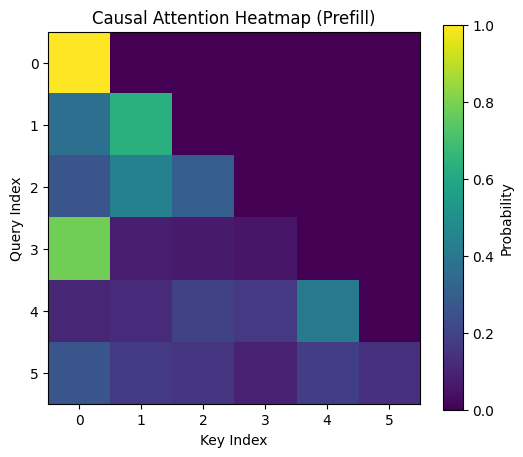

In [9]:
batch_size = 1
prompt_length = 6
embed_dim = 8
head_dim = 8

# TODO: Initialize random tensor for prompt embeddings (shape: batch_size, prompt_length, embed_dim)
X = torch.randn(batch_size, prompt_length, embed_dim, device=device)

# TODO: Initialize projection weights Wq, Wk, Wv (shape: embed_dim, head_dim)
Wq = torch.randn(embed_dim, head_dim, device=device) / math.sqrt(embed_dim)
Wk = torch.randn(embed_dim, head_dim, device=device) / math.sqrt(embed_dim)
Wv = torch.randn(embed_dim, head_dim, device=device) / math.sqrt(embed_dim)

# TODO: Implement manual causal attention
# 1. Q, K, V projections
Q = torch.matmul(X, Wq)
K = torch.matmul(X, Wk)
V = torch.matmul(X, Wv)

# 2. scores = QK^T / sqrt(d)
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(head_dim)

# 3. apply causal mask
mask = torch.triu(torch.ones(prompt_length, prompt_length, device = device), diagonal=1).bool()
scores.masked_fill_(mask, float('-inf'))

# 4. probabilities = softmax(scores)
probs = torch.softmax(scores, dim = -1)

# 5. output = probabilities * V
output = torch.matmul(probs, V)

# TODO: Visualize the causal attention matrix as a heatmap using matplotlib

# Print shapes for verification
print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print(f"Attention scores shape: {scores.shape}")
print(f"Output shape: {output.shape}")

# 4. Visualize the causal attention matrix
plt.figure(figsize=(6, 5))
plt.imshow(probs[0].detach().cpu().numpy(), cmap='viridis')
plt.colorbar(label='Probability')
plt.title('Causal Attention Heatmap (Prefill)')
plt.xlabel('Key Index')
plt.ylabel('Query Index')
plt.show()

## Section 4 — Prefill

During prefill, all prompt positions can be processed in parallel while respecting the causal mask.

Here, you will run the entire prompt through attention, print the shapes of Q, K, V, and the outputs, and save the resulting K and V tensors to act as our initial **KV cache**.

### Note: Prefill vs. Decode Architecture

```mermaid
graph TD
    A[Prompt Tokens] --> B[Embedding]
    B --> C[Parallel Attention Computation]
    C --> D[Generate First Token]
    C --> E[Store K and V in Cache]
    D --> F[Decode Iteration]
    E --> F
```

**Key Concept:** During Prefill, we process $N$ tokens at once. During Decode, we process only $1$ new token. The compute-to-memory ratio shifts dramatically here.

In [10]:
# TODO: Compute Q, K, V for the initial prompt (prefill)
with torch.no_grad():
  Q_prefill = torch.matmul(X, Wq)
  K_prefill = torch.matmul(X, Wk)
  V_prefill = torch.matmul(X, Wv)

# TODO: Print shapes of Q, K, V, attention scores, and output
print(f"Prefill Q shape: {Q_prefill.shape}")
print(f"Prefill K shape: {K_prefill.shape}")
print(f"Prefill V shape: {V_prefill.shape}")

# TODO: Save K and V as the initial KV cache
# kv_cache_k = ...
# kv_cache_v = ...
kv_cache_k = K_prefill.clone()
kv_cache_v = V_prefill.clone()

# TODO: Display KV cache stats
print(f"\n--- KV Cache Initialized ---")
print(f"Tokens cached: {prompt_length}")
print(f"K cache shape: {kv_cache_k.shape} (Batch, Seq, Dim)")
print(f"V cache shape: {kv_cache_v.shape} (Batch, Seq, Dim)")

# print(f"Tokens cached = {prompt_length}")
# print(f"K cache shape = {kv_cache_k.shape}")
# print(f"V cache shape = {kv_cache_v.shape}")

bytes_per_param = kv_cache_k.element_size()
total_bytes = (kv_cache_k.nelement() + kv_cache_v.nelement()) * bytes_per_param
print(f"Cache size: {total_bytes} bytes")

Prefill Q shape: torch.Size([1, 6, 8])
Prefill K shape: torch.Size([1, 6, 8])
Prefill V shape: torch.Size([1, 6, 8])

--- KV Cache Initialized ---
Tokens cached: 6
K cache shape: torch.Size([1, 6, 8]) (Batch, Seq, Dim)
V cache shape: torch.Size([1, 6, 8]) (Batch, Seq, Dim)
Cache size: 384 bytes


## Section 5 — Decode without KV cache

Now we append one new token at a time. In this section, implement an intentionally **inefficient** decode path. For every new token added, recompute Q, K, and V for the *entire* sequence from scratch.

We will simulate 20 decode steps and track the metrics.

In [16]:
num_decode_steps = 20
uncached_metrics = []
generated_new_tokens = [] # Store new tokens to reuse in cached decode

# Current sequence acts as our growing input
current_X = X.clone()

for step in range(num_decode_steps):
    # Simulate adding a new token representation
    new_token = torch.randn(batch_size, 1, embed_dim, device=device)
    generated_new_tokens.append(new_token) # Store the generated token
    current_X = torch.cat([current_X, new_token], dim=1)
    seq_len = current_X.shape[1]


    # TODO: Start timer (use torch.cuda.synchronize() if on GPU)
    if torch.cuda.is_available():
      torch.cuda.synchronize()
    start_time = time.perf_counter()


    # TODO: Recompute Q, K, V for the entire current_X
    Q_full = torch.matmul(current_X, Wq)
    K_full = torch.matmul(current_X, Wk)
    V_full = torch.matmul(current_X, Wv)

    # TODO: Compute attention for the final token
    Q_last = Q_full[:, -1:, :]

    scores_full =torch.matmul(Q_last, K_full.transpose(-2, -1)) / math.sqrt(head_dim)

    probs_full = torch.softmax(scores_full, dim = -1)

    output_full = torch.matmul(probs_full, V_full)
    # TODO: Stop timer
    if torch.cuda.is_available():
      torch.cuda.synchronize()
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time


    # TODO: Track sequence length, token projections recomputed, elapsed time, attention-score elements
    uncached_metrics.append({
        'seq_len': seq_len,
        'tokens_projected': seq_len, # Every token in the sequence gets re-projected
        'elapsed_time': elapsed_time,
        'attention_score_elements': seq_len # Q_last (1) x K_full (seq_len) results in 1*seq_len elements
    })
# TODO: Store metrics in a pandas DataFrame: df_uncached

df_uncached = pd.DataFrame(uncached_metrics)

## Section 6 — Decode with KV cache

This time, implement the **cached** path. For each new token, compute Q, K, and V *only* for the new token. Append the new K and V to the cache, and attend the new query against all cached keys and values.

### Deep Dive: KV Caching

Without a KV cache, for a sequence of length $L$, the attention computation is $O(L^2)$. By caching, we turn the incremental step into $O(L)$ because we only project the *new* token and reuse the $L-1$ previous Keys and Values.

**Memory Note:** While we save time, we pay in memory. The cache must stay in GPU memory for the duration of the request.

In [17]:
cached_metrics = [] #init empty list to store perf metrics

# TODO: Initialize cache from the prefill stage (Section 4)
current_cache_k = kv_cache_k.clone()
current_cache_v = kv_cache_v.clone()

for step in range(num_decode_steps):
    # Simulate the same new token (to ensure identical behavior)
    # Use the token generated and stored from the uncached loop
    new_token = generated_new_tokens[step]

    # TODO: Start timer
    if torch.cuda.is_available():
      torch.cuda.synchronize()
    start_time = time.perf_counter()

    # TODO: Compute Q, K, V ONLY for the new token
    Q_new_token = torch.matmul(new_token, Wq)
    K_new_token = torch.matmul(new_token, Wk)
    V_new_token = torch.matmul(new_token, Wv)

    # TODO: Append new K and V to the cache
    current_cache_k = torch.cat([current_cache_k, K_new_token], dim = 1)
    current_cache_v = torch.cat([current_cache_v, V_new_token], dim = 1)

    seq_len_cached = current_cache_k.shape[1]


    # TODO: Attend the new query against ALL cached keys and values
    scores_cached = torch.matmul(Q_new_token, current_cache_k.transpose(-2, -1)) / math.sqrt(head_dim)
    probs_cached = torch.softmax(scores_cached, dim = -1)
    output_cached = torch.matmul(probs_cached, current_cache_v)

    # TODO: Stop timer
    if torch.cuda.is_available():
      torch.cuda.synchronize()
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time


    #kv cache bytes
    kv_cache_bytes = (current_cache_k.nelement() + current_cache_v.nelement()) * current_cache_k.element_size()


    # TODO: Track sequence length, token projections, elapsed time, attention elements, KV cache bytes
    cached_metrics.append({
        'seq_len': seq_len_cached, # Current sequence length.
        'tokens_projected': 1, # Only 1 new token is projected at each step.
        'elapsed_time': elapsed_time, # Time taken for this step.
        'attention_score_elements': seq_len_cached, # Q_new (1) x K_cached (seq_len) results in 1*seq_len elements.
        'kv_cache_bytes': kv_cache_bytes # Current KV cache memory usage.
    })

# TODO: Store metrics in a pandas DataFrame: df_cached
df_cached = pd.DataFrame(cached_metrics)

## Section 7 — Correctness validation

Mathematically, reusing cached K/V is equivalent to recomputing previous K/V, assuming the model weights and token history remain exactly the same.

Let's assert that the final token's output from the uncached and cached implementations are numerically identical.

In [18]:
uncached_final_output = output_full # From the last iteration of the uncached loop
cached_final_output = output_cached # From the last iteration of the cached loop

torch.testing.assert_close(uncached_final_output, cached_final_output)
print("Validation successful! Cached and uncached outputs match.")

Validation successful! Cached and uncached outputs match.


## Section 8 — Comparison plots

Visualize the performance characteristics of both approaches. Create one figure per chart (no subplots).

In [ ]:
# TODO: Plot 1: Token projections recomputed per decode step
# plt.figure()
# ...

# TODO: Plot 2: Cumulative projected-token work
# plt.figure()
# ...

# TODO: Plot 3: Elapsed time per step
# plt.figure()
# ...

# TODO: Plot 4: KV-cache memory growth
# plt.figure()
# ...

# TODO: Plot 5: Attention-score elements per step
# plt.figure()
# ...

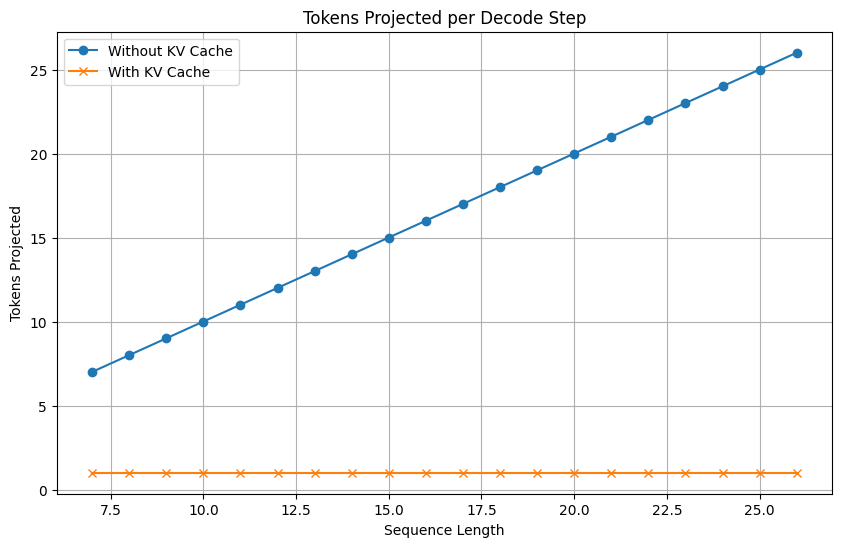

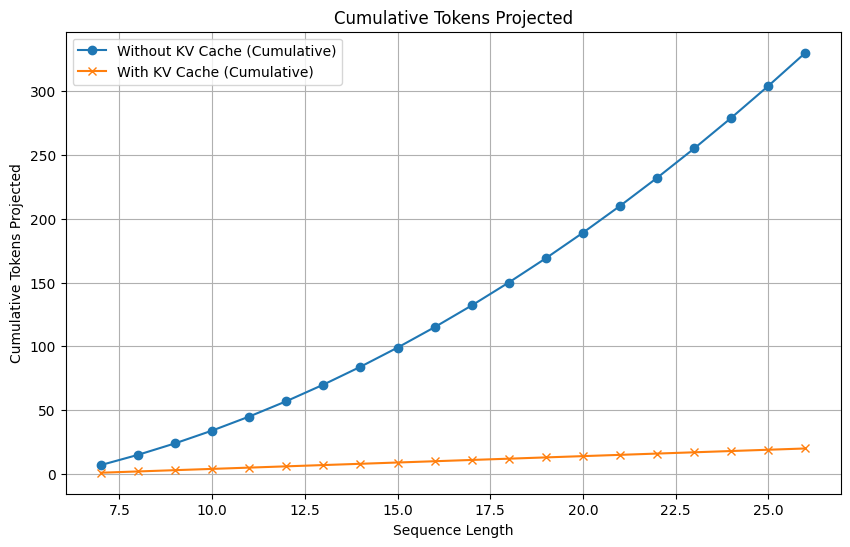

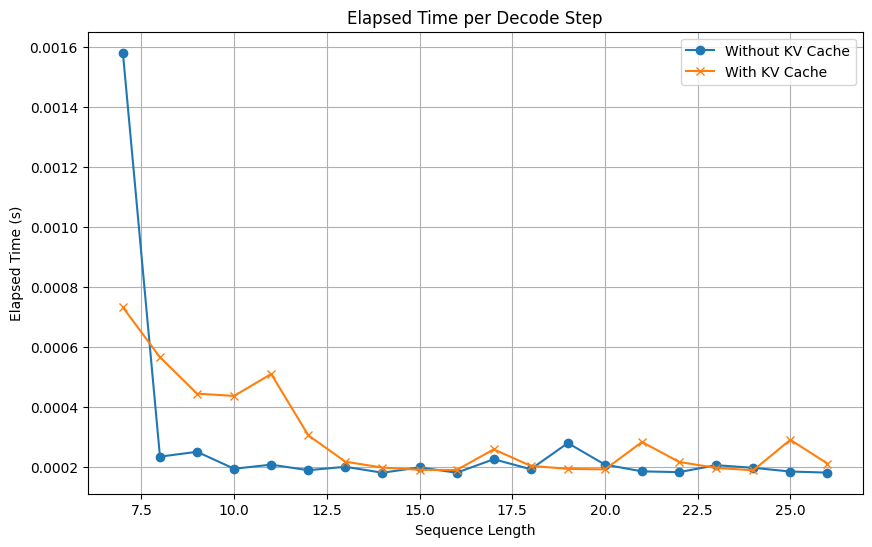

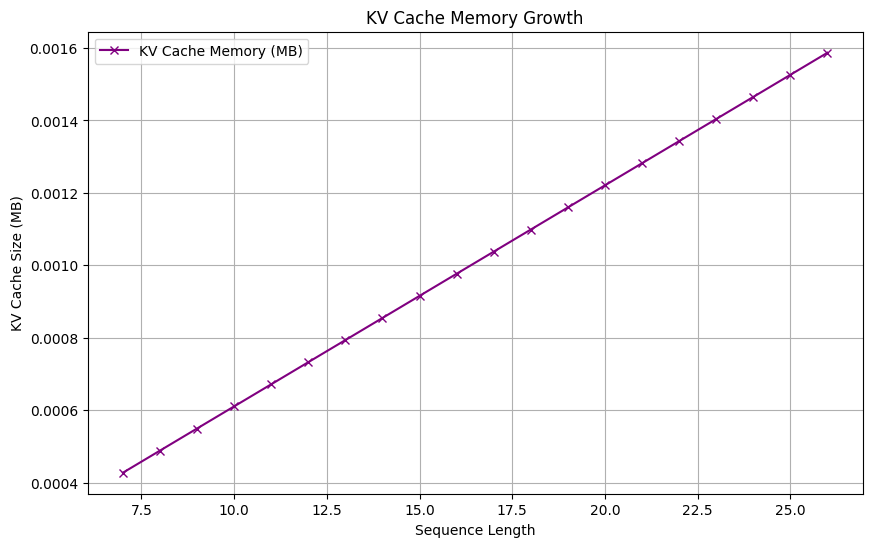

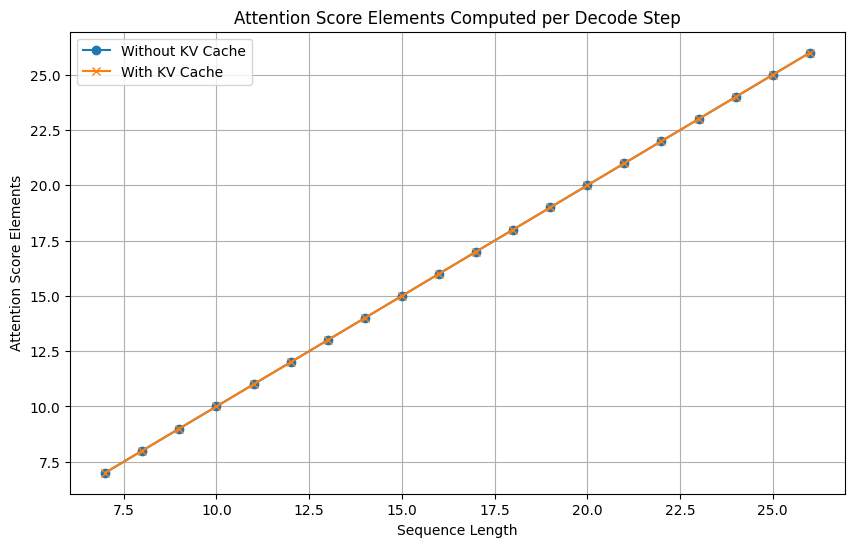

In [19]:
import matplotlib.pyplot as plt

# TODO: Plot 1: Token projections recomputed per decode step
plt.figure(figsize=(10, 6))
plt.plot(df_uncached['seq_len'], df_uncached['tokens_projected'], label='Without KV Cache', marker='o')
plt.plot(df_cached['seq_len'], df_cached['tokens_projected'], label='With KV Cache', marker='x')
plt.title('Tokens Projected per Decode Step')
plt.xlabel('Sequence Length')
plt.ylabel('Tokens Projected')
plt.legend()
plt.grid(True)
plt.show()

# TODO: Plot 2: Cumulative projected-token work
plt.figure(figsize=(10, 6))
plt.plot(df_uncached['seq_len'], df_uncached['tokens_projected'].cumsum(), label='Without KV Cache (Cumulative)', marker='o')
plt.plot(df_cached['seq_len'], df_cached['tokens_projected'].cumsum(), label='With KV Cache (Cumulative)', marker='x')
plt.title('Cumulative Tokens Projected')
plt.xlabel('Sequence Length')
plt.ylabel('Cumulative Tokens Projected')
plt.legend()
plt.grid(True)
plt.show()

# TODO: Plot 3: Elapsed time per step
plt.figure(figsize=(10, 6))
plt.plot(df_uncached['seq_len'], df_uncached['elapsed_time'], label='Without KV Cache', marker='o')
plt.plot(df_cached['seq_len'], df_cached['elapsed_time'], label='With KV Cache', marker='x')
plt.title('Elapsed Time per Decode Step')
plt.xlabel('Sequence Length')
plt.ylabel('Elapsed Time (s)')
plt.legend()
plt.grid(True)
plt.show()

# TODO: Plot 4: KV-cache memory growth
# Note: This metric is only applicable to the cached approach
plt.figure(figsize=(10, 6))
plt.plot(df_cached['seq_len'], df_cached['kv_cache_bytes'] / (1024**2), label='KV Cache Memory (MB)', marker='x', color='purple')
plt.title('KV Cache Memory Growth')
plt.xlabel('Sequence Length')
plt.ylabel('KV Cache Size (MB)')
plt.legend()
plt.grid(True)
plt.show()

# TODO: Plot 5: Attention-score elements per step
plt.figure(figsize=(10, 6))
plt.plot(df_uncached['seq_len'], df_uncached['attention_score_elements'], label='Without KV Cache', marker='o')
plt.plot(df_cached['seq_len'], df_cached['attention_score_elements'], label='With KV Cache', marker='x')
plt.title('Attention Score Elements Computed per Decode Step')
plt.xlabel('Sequence Length')
plt.ylabel('Attention Score Elements')
plt.legend()
plt.grid(True)
plt.show()

## Section 9 — Memory calculation

The KV cache grows linearly with sequence length. The simplified formula for one layer is:
`KV bytes = 2 × sequence_length × number_of_kv_heads × head_dimension × bytes_per_element`

Write a function to estimate the size of the KV cache across multiple layers and batches.

In [22]:
def estimate_kv_cache_bytes(
    num_layers: int,
    num_kv_heads: int,
    head_dim: int,
    sequence_length: int,
    batch_size: int,
    dtype_bytes: int = 2, # e.g., 2 for float16
):
    # TODO: Implement the formula
    # The formula provided is: 2 * sequence_length * number_of_kv_heads * head_dimension * bytes_per_element
    # This is for one layer and one batch. We need to multiply by num_layers and batch_size.
    kv_bytes_per_head_per_layer = sequence_length * head_dim * dtype_bytes # K or V for one head, one layer
    total_kv_bytes = 2 * num_layers * num_kv_heads * kv_bytes_per_head_per_layer * batch_size
    return total_kv_bytes

# TODO: Example 1 - The toy model from this notebook
# Our toy model has one attention head, so num_kv_heads = 1.
# The head_dim is 8.
# We are simulating a batch_size of 1.
# Let's assume a sequence_length of 26 (from our decode simulation) and 1 layer.
print(f"\n--- KV Cache Estimation for Toy Model ---")
toy_model_cache_bytes = estimate_kv_cache_bytes(
    num_layers=1,
    num_kv_heads=1,
    head_dim=head_dim, # From our setup: 8
    sequence_length=df_cached['seq_len'].max(), # Max sequence length from our decode
    batch_size=batch_size, # From our setup: 1
    dtype_bytes=4 # Assuming float32 for this calculation, as we used for tensors. If float16, use 2.
)
print(f"Toy Model KV Cache (Seq Len {df_cached['seq_len'].max()}): {toy_model_cache_bytes / (1024**2):.4f} MB")

# TODO: Example 2 - A small realistic model configuration (e.g. LLaMA 7B)
# LLaMA 7B parameters (example values, may vary slightly):
# num_layers: 32
# num_kv_heads: 32 (for LLaMA, often same as num_attention_heads for GQA/MQA, but some models separate)
# head_dim: 128 (embed_dim / num_heads = 4096 / 32)
# sequence_length: 2048 (typical context window)
# batch_size: 1 (single user inference)
# dtype_bytes: 2 (float16)
print(f"\n--- KV Cache Estimation for LLaMA 7B (Example) ---")
llama_7b_cache_bytes = estimate_kv_cache_bytes(
    num_layers=32,
    num_kv_heads=32,
    head_dim=128,
    sequence_length=2048,
    batch_size=1,
    dtype_bytes=2
)
print(f"LLaMA 7B KV Cache (Seq Len 2048, fp16, Batch 1): {llama_7b_cache_bytes / (1024**2):.4f} MB")

# TODO: Example 3 - A larger long-context model configuration
# Example: A model with a larger context window or more layers/heads
# num_layers: 64
# num_kv_heads: 64
# head_dim: 128
# sequence_length: 8192 (long context)
# batch_size: 4 (example for multiple concurrent inferences)
# dtype_bytes: 2 (float16)
print(f"\n--- KV Cache Estimation for Long-Context Model (Example) ---")
long_context_cache_bytes = estimate_kv_cache_bytes(
    num_layers=64,
    num_kv_heads=64,
    head_dim=128,
    sequence_length=8192,
    batch_size=4,
    dtype_bytes=2
)
print(f"Long-Context Model KV Cache (Seq Len 8192, fp16, Batch 4): {long_context_cache_bytes / (1024**3):.4f} GB")



--- KV Cache Estimation for Toy Model ---
Toy Model KV Cache (Seq Len 26): 0.0016 MB

--- KV Cache Estimation for LLaMA 7B (Example) ---
LLaMA 7B KV Cache (Seq Len 2048, fp16, Batch 1): 1024.0000 MB

--- KV Cache Estimation for Long-Context Model (Example) ---
Long-Context Model KV Cache (Seq Len 8192, fp16, Batch 4): 64.0000 GB


### Architectural Diagram: Memory Layout

| Layer | K-Cache | V-Cache |
| :--- | :--- | :--- |
| 1 | [batch, heads, seq, dim] | [batch, heads, seq, dim] |
| 2 | [batch, heads, seq, dim] | [batch, heads, seq, dim] |
| ... | ... | ... |
| N | [batch, heads, seq, dim] | [batch, heads, seq, dim] |

*Total Memory usage grows linearly with the number of layers and sequence length.*

## Section 10 — Prefill versus decode intuition

* **Prefill**: Processes many tokens together, utilizes large matrix multiplications, exposes more parallelism, and is heavily compute-bound.
* **Decode**: Processes one new token per sequence per iteration, repeatedly reads model weights and a growing KV cache, has less arithmetic density, and is largely memory-bandwidth bound.

*(Note: Actual behavior varies heavily by hardware, batch size, and kernel implementation.)*

## Section 11 — Connection to real runtimes

While our toy implementation caches tensors directly, production runtimes like **vLLM**, **SGLang**, and **TensorRT-LLM** add:
* Paged or pooled KV allocation (managing fragmentation)
* Continuous batching / scheduling
* Prefix reuse (RadixAttention)
* CUDA Graphs
* Fused attention kernels (FlashAttention, PagedAttention)

### Personal Note: Why Memory Bandwidth Matters

Modern GPUs like the A100 or H100 are so fast at computation that for small batch sizes, the "compute" part of decoding takes almost no time. The bottleneck is literally moving the weights and the cache from the HBM memory chip to the actual GPU cores. This is why techniques like **FlashAttention** and **PagedAttention** are so revolutionary—they optimize memory movement, not just FLOPs.

## Section 12 — Knowledge check

Try answering these questions before expanding the details block:

1. Why can cached K and V be reused but the new query must be computed?
2. Why does KV memory grow linearly with sequence length?
3. Why does decode still attend to all previous tokens?
4. What would invalidate previously cached KV?
5. Why is KV caching different from prefix caching?
6. Why does prefill parallelize better than decode?
7. Which dimensions determine KV-cache memory?
8. Why can decode become memory-bandwidth limited?

<details>
<summary><b>Click to reveal answers</b></summary>

1. The new token needs to query the historical context to decide what to pay attention to. Its Query vector is derived from its own unique embedding, whereas the historical Keys/Values don't change because the past sequence is fixed.
2. For every new token generated, we add a new Key vector and a new Value vector to the cache.
3. Causal self-attention means the current token needs information from all preceding tokens to predict the next logical token.
4. Changing the prompt, using a different model, or modifying generation parameters that affect the prompt text.
5. KV caching stores exact K/V vectors token-by-token during generation. Prefix caching stores K/V for shared, reusable system prompts across multiple completely separate requests.
6. Prefill involves multiplying an $N \times d$ matrix by $d \times d$ weight matrices, which parallelizes beautifully on GPUs. Decode does $1 \times d$ matrix multiplications, heavily underutilizing the GPU's compute cores.
7. Batch size, sequence length, number of layers, number of KV heads, head dimension, and data type size.
8. Since compute is low ($1 \times d$ operations), the bottleneck becomes the speed at which the GPU can fetch the massive model weights and the massive KV cache from HBM (High Bandwidth Memory) to the compute cores for every single step.

</details>

## Section 13 — Final takeaway

* **Prefill** computes and stores K/V for the initial prompt.
* **Decode** computes K/V only for each new token.
* The **KV cache** avoids recomputing historical attention states.
* The cache reduces computation but consumes memory that grows linearly with context length.
* Inference runtimes exist partly to manage this massive and growing KV state efficiently across many concurrent users.